# Installing the required libraries
Run the following command in the terminal to install all required libraries:

python -m pip install -r requirements.txt

In [4]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import subprocess
from datasets import load_dataset
import random
from collections import Counter

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import sys
from tqdm import tqdm
#Garbage collector
import gc

# Testing for CUDA
Given the size of the dataset, this is an important feature to have available

In [6]:
tf.debugging.set_log_device_placement(False)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(gpus)

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Python: 3.11.9 (main, Oct  3 2026, 22:16:31) [GCC 15.2.0]
TensorFlow: 2.15.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 1 - Getting the dataset

In [7]:
# Downloads the dataset's images from GitHub
dataset_path = Path("PlantVillage-Dataset")
repo_url = "https://github.com/spMohanty/PlantVillage-Dataset.git"

if dataset_path.exists():
    print(f"Dataset already exists: {dataset_path.resolve()}")
else:
    print("Dataset not found. Cloning...")
    subprocess.run(
        ["git", "clone", repo_url, str(dataset_path)],
        check=True
    )
    print(f"Dataset cloned to: {dataset_path.resolve()}")

Dataset already exists: /mnt/c/Users/luis/Documents/Facul/Project-Healthy-and-Diseased-Plant-Leaves/PlantVillage-Dataset


In [9]:
# Downloads the paths to the images, along with it's descriptors
# load_dataset automatically checks if it's already been downloaded, so this block can be ran everytime without major delays
dataset = load_dataset(
    "mohanty/PlantVillage",
    "default"
)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 129783
    })
    test: Dataset({
        features: ['text'],
        num_rows: 33133
    })
})


# 2.1 - Checking the dataset structure and grouping by color type

In [10]:
for split in ["train", "test"]:
    types = []

    for item in tqdm(dataset[split]):
        path = Path(item["text"])
        parts = path.parts

        # raw/<type>/...
        image_type = parts[parts.index("raw") + 1]
        types.append(image_type)

    print(f"\n===== {split.upper()} =====")

    # Find contiguous ranges for each type
    ranges = {
        "color": [],
        "grayscale": [],
        "segmented": []
    }

    start = 0
    current = types[0]

    for i in range(1, len(types)):
        if types[i] != current:
            ranges[current].append((start, i - 1))
            start = i
            current = types[i]

    ranges[current].append((start, len(types) - 1))

    # Print each type separately
    for image_type in ["color", "grayscale", "segmented"]:
        print(f"\n{image_type.upper()}:")

        if not ranges[image_type]:
            print("  Not present")
        else:
            for start, end in ranges[image_type]:
                print(
                    f"  Indexes: {start:,} - {end:,} "
                    f"({end - start + 1:,} images)"
                )

100%|███████████████████████████████████████████████████████████████████████| 129783/129783 [00:01<00:00, 65689.66it/s]



===== TRAIN =====

COLOR:
  Indexes: 0 - 43,595 (43,596 images)

GRAYSCALE:
  Indexes: 43,596 - 86,798 (43,203 images)

SEGMENTED:
  Indexes: 86,799 - 129,782 (42,984 images)


100%|█████████████████████████████████████████████████████████████████████████| 33133/33133 [00:00<00:00, 68137.99it/s]


===== TEST =====

COLOR:
  Indexes: 0 - 10,708 (10,709 images)

GRAYSCALE:
  Indexes: 10,709 - 21,810 (11,102 images)

SEGMENTED:
  Indexes: 21,811 - 33,132 (11,322 images)


In [11]:
train_color = []
train_grayscale = []
train_segmented = []

test_color = []
test_grayscale = []
test_segmented = []

# Separate training set
for item in tqdm(dataset["train"]):
    path = Path(item["text"])
    image_type = path.parts[path.parts.index("raw") + 1]

    if image_type == "color":
        train_color.append(item)
    elif image_type == "grayscale":
        train_grayscale.append(item)
    elif image_type == "segmented":
        train_segmented.append(item)

# Separate test set
for item in tqdm(dataset["test"]):
    path = Path(item["text"])
    image_type = path.parts[path.parts.index("raw") + 1]

    if image_type == "color":
        test_color.append(item)
    elif image_type == "grayscale":
        test_grayscale.append(item)
    elif image_type == "segmented":
        test_segmented.append(item)


# Check sizes
print("Training:")
print("  Color:", len(train_color))
print("  Grayscale:", len(train_grayscale))
print("  Segmented:", len(train_segmented))

print("\nTest:")
print("  Color:", len(test_color))
print("  Grayscale:", len(test_grayscale))
print("  Segmented:", len(test_segmented))

100%|█████████████████████████████████████████████████████████████████████████| 33133/33133 [00:00<00:00, 56734.67it/s]

Training:
  Color: 43596
  Grayscale: 43203
  Segmented: 42984

Test:
  Color: 10709
  Grayscale: 11102
  Segmented: 11322


# 2.2 - Example images

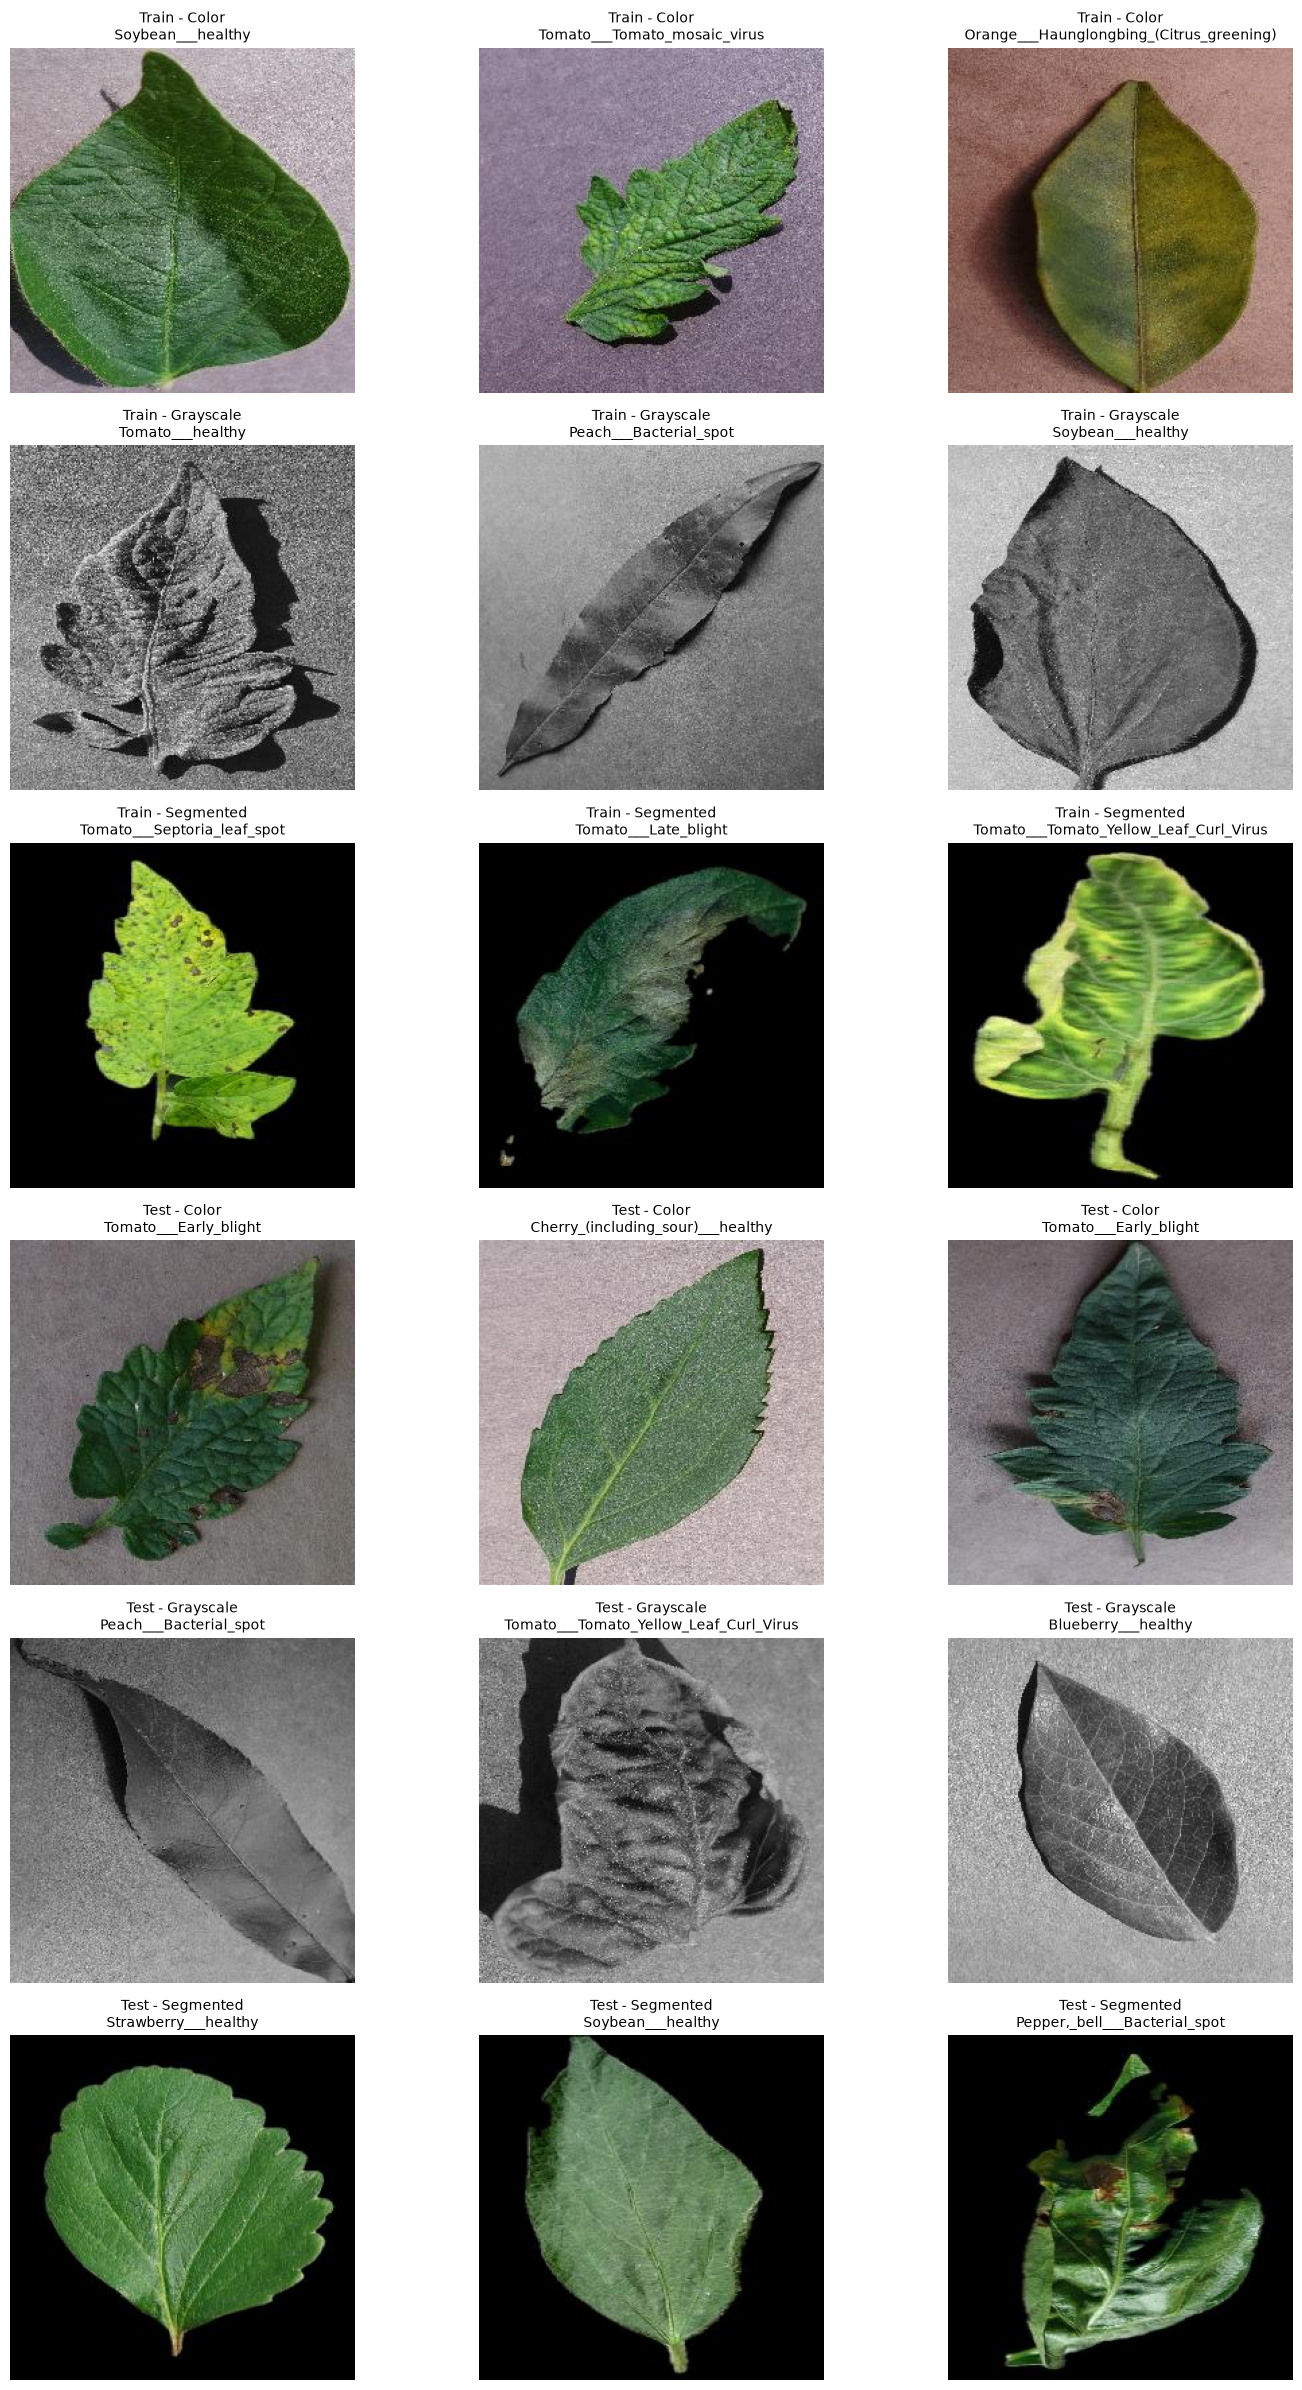

In [12]:
arrays = {
    "Train - Color": train_color,
    "Train - Grayscale": train_grayscale,
    "Train - Segmented": train_segmented,
    "Test - Color": test_color,
    "Test - Grayscale": test_grayscale,
    "Test - Segmented": test_segmented
}

fig, axes = plt.subplots(6, 3, figsize=(15, 24))

for row, (name, array) in enumerate(arrays.items()):
    samples = random.sample(array, 3)

    for col, item in enumerate(samples):
        path = Path(item["text"])

        # raw/<type>/<class>/<filename>
        class_name = path.parts[path.parts.index("raw") + 2]

        image_path = Path("PlantVillage-Dataset") / item["text"]
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(
            f"{name}\n{class_name}",
            fontsize=10
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# 2.3 - Checking the possible conditions

In [13]:
disease_counts = Counter()

for split in ["train", "test"]:
    for item in tqdm(dataset[split]):
        path = Path(item["text"])
        class_name = path.parts[path.parts.index("raw") + 2]
        disease = class_name.split("___")[1]
        disease_counts[disease] += 1

diseases = sorted(disease_counts)

total = sum(disease_counts.values())

print(f"Total conditions: {len(diseases)}")
print(f"Total images: {total}\n")

for disease, count in disease_counts.most_common():
    percentage = count / total * 100
    print(f"{disease:45s} {count:6d} ({percentage:6.2f}%)")

100%|█████████████████████████████████████████████████████████████████████████| 33133/33133 [00:00<00:00, 56190.95it/s]

Total conditions: 21
Total images: 162916

healthy                                        45252 ( 27.78%)
Haunglongbing_(Citrus_greening)                16521 ( 10.14%)
Bacterial_spot                                 16263 (  9.98%)
Tomato_Yellow_Leaf_Curl_Virus                  16071 (  9.86%)
Late_blight                                     8727 (  5.36%)
Powdery_mildew                                  8661 (  5.32%)
Early_blight                                    6000 (  3.68%)
Black_rot                                       5403 (  3.32%)
Septoria_leaf_spot                              5313 (  3.26%)
Spider_mites Two-spotted_spider_mite            5028 (  3.09%)
Target_Spot                                     4212 (  2.59%)
Esca_(Black_Measles)                            4150 (  2.55%)
Common_rust_                                    3576 (  2.19%)
Leaf_scorch                                     3327 (  2.04%)
Leaf_blight_(Isariopsis_Leaf_Spot)              3228 (  1.98%)
Northern_Lea

As can be seen, there are no issues with the possible conditions. There are no spelling errors, and all conditions are clearly defined and correctly identified.

# 2.4 - Checking the images sizes

Since the code above takes a long time to run, it's output is below:

- Train - Color: {(256, 256)}
- Train - Grayscale: {(256, 256)}
- Train - Segmented: {(324, 512), (470, 512), (335, 512), (256, 256), (466, 512)}
- Test - Color: {(256, 256)}
- Test - Grayscale: {(256, 256)}
- Test - Segmented: {(256, 256)}

# 3 - Separating the sets

In [16]:
# Classifies each image
def load_dataset(dataset, possible_diseases):
    paths = []
    labels = []

    disease_to_index = {
        disease: i
        for i, disease in enumerate(possible_diseases)
    }

    for item in tqdm(dataset):
        path = Path(item["text"])

        # raw/<type>/<class>/<filename>
        class_name = path.parts[path.parts.index("raw") + 2]

        # Extract disease
        disease = class_name.split("___")[1]

        paths.append(
            str(Path("PlantVillage-Dataset") / item["text"])
        )
        labels.append(disease_to_index[disease])

    return np.array(paths), np.array(labels, dtype=np.int32)

In [75]:
# Loads the images as needed, saving memory usage
# The code is currently made for the colored images, which have consistent sizes and 3 channels
def load_image(path, label):
    image = tf.io.read_file(path)
    
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

# Separates the sets in batches, allowing for better control of the memory usage, espcially to fit the GPU
def create_tf_dataset(X, y, batch_size=16, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        ds = ds.shuffle(len(X))

    ds = (
        ds
        # load_image been used for every batch
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return ds

In [89]:
# Clean the variables if they already exist
# Without cleaning, if there isn't enough available memory the following code won't work adequately
for var in ["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"]:
    if var in globals():
        del globals()[var]
tf.keras.backend.clear_session()
gc.collect()

# Randomizes some images for training, evaluating and testing
random.seed(42)
reduced_train = random.sample(train_color, len(train_color)//2)
train_set, validation_set = train_test_split(
    reduced_train,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

test_set = random.sample(test_color, len(test_color))

# Classifies each image
X_train, y_train = load_dataset(train_set, diseases)
X_val, y_val = load_dataset(validation_set, diseases)
X_test, y_test = load_dataset(test_set, diseases)

100%|████████████████████████████████████████████████████████████████████████| 10709/10709 [00:00<00:00, 115160.07it/s]


In [90]:
# Creates the batched datasets for the model
BATCH_SIZE = 16

train_ds = create_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True)
val_ds   = create_tf_dataset(X_val,   y_val,   BATCH_SIZE)
test_ds  = create_tf_dataset(X_test,  y_test,  BATCH_SIZE)

# 4 - Models

# 4.1 - Functions for testing the models

In [80]:
def test_model(model, train_dataset, valuation_dataset, patience=5, learning_rate=0.0001, epochs=10):
    # If the model isn't learning, stops it early to save on processing time
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model.fit(
        train_dataset,
        validation_data=valuation_dataset,
        epochs=epochs,
        callbacks=[early_stopping]
    )

    return history

def plot_model_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Model Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def model_confusion_matrix(model, test_ds, diseases):
    # Predictions
    y_pred = model.predict(test_ds)
    y_pred = y_pred.argmax(axis=1)

    # Get true labels from the dataset
    y_test = np.concatenate([
        labels.numpy()
        for _, labels in test_ds
    ])

    # Forces all 21 classes to be included
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=range(len(diseases))
    )

    fig, ax = plt.subplots(figsize=(14, 14))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=diseases
    )

    disp.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=True
    )

    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

# 4.2.1 - First model

In [81]:
model = tf.keras.Sequential([
    # Input: 256x256 RGB image
    tf.keras.layers.Input(shape=(256, 256, 3)),

    # Block 1
    # 32 filters of size 3x3 learn basic visual features such as edges, color transitions, and simple textures.
    # "same" padding keeps the image dimensions at 256x256.
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),

    # Reduce the spatial dimensions by half.
    # 256x256 -> 128x128.
    # This reduces computation while retaining the strongest features.
    tf.keras.layers.MaxPooling2D(2),

    # Block 2
    # 64 filters allow the network to detect more complex patterns by combining features learned in the previous block.
    # Double the amount of neurons to better extract information from the reduced amount of data (128x128)
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),

    # Reduce the spatial dimensions by half again.
    # 128x128 -> 64x64.
    tf.keras.layers.MaxPooling2D(2),

    # Block 3
    # 128 filters allow the network to learn increasingly complex and abstract features, such as disease-related patterns,
    # Yet again, double the amount of neurons
    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),

    # Reduce the spatial dimensions once more.
    # 64x64 -> 32x32.
    tf.keras.layers.MaxPooling2D(2),

    # Classifier
    # Instead of flattening all 32x32x128 values into a very large vector,
    # GlobalAveragePooling2D calculates the average activation of each of the 128 feature maps.
    # 32x32x128 -> 128 values.
    tf.keras.layers.GlobalAveragePooling2D(),

    # Combine the extracted features to make the final classification.
    tf.keras.layers.Dense(128, activation="relu"),

    # Final classification layer.
    # There are 21 possible plant conditions, so there are 21 neurons.
    # Softmax converts their outputs into probabilities that sum to 1.
    tf.keras.layers.Dense(21, activation="softmax")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 256, 256, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 128, 128, 32)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 128, 128, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 64, 64, 64)        0         
 g2D)                                                   

In [91]:
history = test_model(model=model, epochs=30, train_dataset=train_ds, valuation_dataset=val_ds)

Epoch 1/30
1090/1090 [==============================] - 144s 131ms/step - loss: 1.2436 - accuracy: 0.6064 - val_loss: 1.1835 - val_accuracy: 0.6264
Epoch 2/30
1090/1090 [==============================] - 134s 123ms/step - loss: 1.1133 - accuracy: 0.6450 - val_loss: 1.1429 - val_accuracy: 0.6429
Epoch 3/30
1090/1090 [==============================] - 134s 123ms/step - loss: 1.0104 - accuracy: 0.6787 - val_loss: 0.9299 - val_accuracy: 0.7131
Epoch 4/30
1090/1090 [==============================] - 134s 123ms/step - loss: 0.9163 - accuracy: 0.7053 - val_loss: 0.8519 - val_accuracy: 0.7286
Epoch 5/30
1090/1090 [==============================] - 134s 123ms/step - loss: 0.8334 - accuracy: 0.7310 - val_loss: 0.7961 - val_accuracy: 0.7530
Epoch 6/30
1090/1090 [==============================] - 134s 123ms/step - loss: 0.7803 - accuracy: 0.7474 - val_loss: 0.7706 - val_accuracy: 0.7564
Epoch 7/30
1090/1090 [==============================] - 134s 123ms/step - loss: 0.7073 - accuracy: 0.7696 - val_

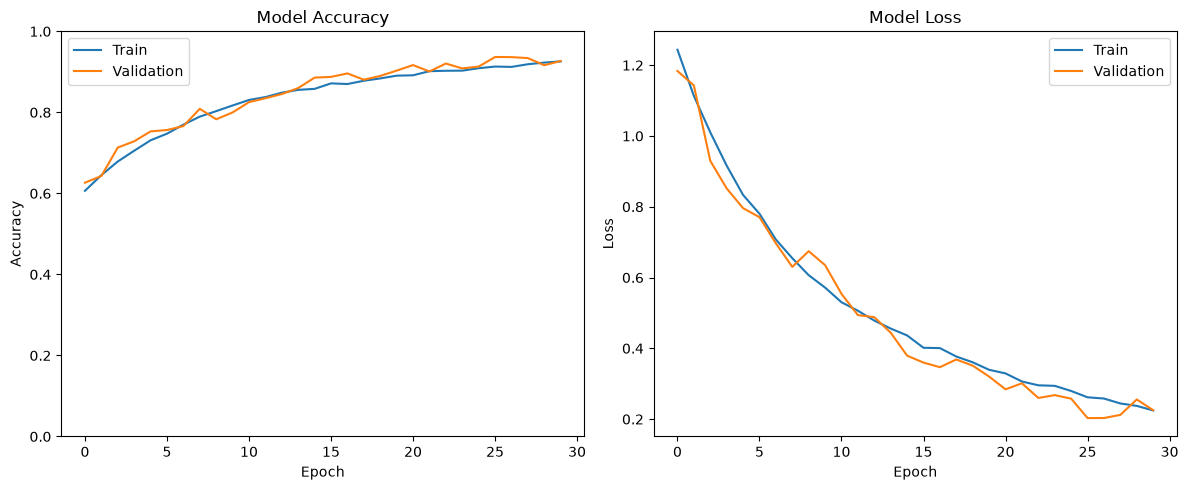

670/670 [==============================] - 22s 33ms/step


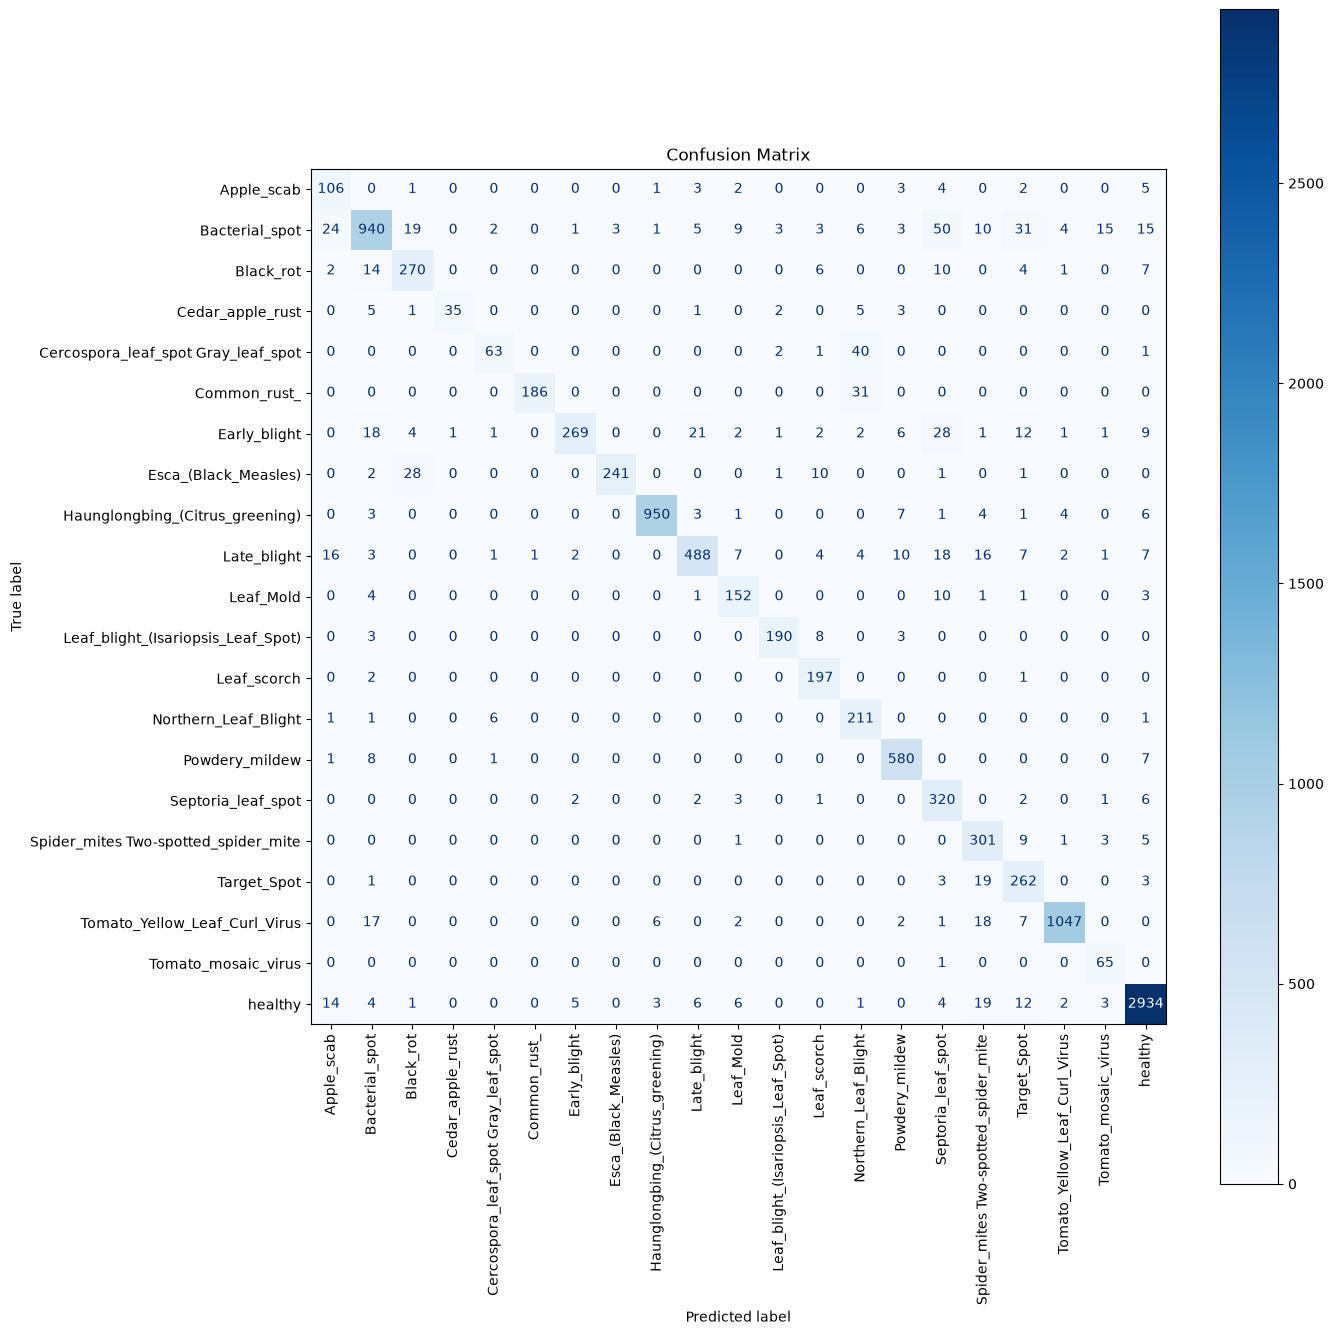

In [92]:
plot_model_history(history)
model_confusion_matrix(model, test_ds, diseases)

A good first model, but there is still room for improvement. For example, 'Cercospora_leaf_spot Gray_leaf_spot' had only a 58.879% accuracy (63/107).